# Dating Apps


# Introduction
In recent years, there has been a massive rise in the usage of dating apps to find love. Many of these apps use sophisticated data science techniques to recommend possible matches to users and to optimize the user experience. These apps give us access to a wealth of information that we’ve never had before about how different people experience romance.

For this project we will be looking a dataset of an app called OKCupid. This App focuses on using multiple choice and short answers to match users.
We will be formulating questions and implementing machine learning techniques to answer those questions, so let's get started

# Exploratory Data Analysis
First, let's load an inspect the data. This will help us to understand what we are working with and check if we need to clean the data

In [1]:
import pandas as pd

In [2]:
profiles = pd.read_csv("profiles.csv")
profiles.head()

,age,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,22,a little extra,strictly anything,socially,never,working on college/university,about me:<br />\n<br />\ni would love to think...,currently working as an international agent fo...,making people laugh.<br />\nranting about a go...,"the way i look. i am a six foot half asian, ha...",...,"south san francisco, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,35,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means.<br />\n1...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,NaN,...,"oakland, california","doesn&rsquo;t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,38,thin,anything,socially,NaN,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,...,"san francisco, california",NaN,straight,has cats,NaN,m,pisces but it doesn&rsquo;t matter,no,"english, french, c++",available
3,23,thin,vegetarian,socially,NaN,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,...,"berkeley, california",doesn&rsquo;t want kids,straight,likes cats,NaN,m,pisces,no,"english, german (poorly)",single
4,29,athletic,NaN,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at:<br />\nhttp://bag...,i smile a lot and my inquisitive nature,...,"san francisco, california",NaN,straight,likes dogs and likes cats,NaN,m,aquarius,no,english,single


In [3]:
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 31 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   essay0       54458 non-null  object 
 7   essay1       52374 non-null  object 
 8   essay2       50308 non-null  object 
 9   essay3       48470 non-null  object 
 10  essay4       49409 non-null  object 
 11  essay5       49096 non-null  object 
 12  essay6       46175 non-null  object 
 13  essay7       47495 non-null  object 
 14  essay8       40721 non-null  object 
 15  essay9       47343 non-null  object 
 16  ethnicity    54266 non-null  object 
 17  height       59943 non-null  float64
 18  income       59946 non-null  int64  
 19  job 

We can see that the text has html entities and tags so in order to create a model we have to get rid of the noise the text can have

In [4]:
import html 
import re

In [5]:
text_columns = [column for column in profiles.columns if profiles[column].dtype == "object"] # Get all columns that has text to clean them
profiles[text_columns] = profiles[text_columns].fillna("") # Replace NaN with empty string to avoid errors
def clean_text(text):
    text = html.unescape(text) # Remove html entities like &amp;
    text = html.unescape(text)  # In case there is a second entity inside another one
    text = re.sub(r"<.*?>", " ", text) # Removes html tags
    text = re.sub(r"[\x00-\x1F\x7F]", "", text) # Removes control chars
    text = re.sub(r"\s+", " ", text).strip() # Normalize spaces
    return text

In [6]:
for column in text_columns:
    profiles[column] = profiles[column].map(clean_text)
profiles[text_columns].head()

,body_type,diet,drinks,drugs,education,essay0,essay1,essay2,essay3,essay4,...,location,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status
0,a little extra,strictly anything,socially,never,working on college/university,about me: i would love to think that i was som...,currently working as an international agent fo...,making people laugh. ranting about a good salt...,"the way i look. i am a six foot half asian, ha...","books: absurdistan, the republic, of mice and ...",...,"south san francisco, california","doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single
1,average,mostly other,often,sometimes,working on space camp,i am a chef: this is what that means. 1. i am ...,dedicating everyday to being an unbelievable b...,being silly. having ridiculous amonts of fun w...,,i am die hard christopher moore fan. i don't r...,...,"oakland, california","doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single
2,thin,anything,socially,,graduated from masters program,"i'm not ashamed of much, but writing public te...","i make nerdy software for musicians, artists, ...",improvising in different contexts. alternating...,my large jaw and large glasses are the physica...,okay this is where the cultural matrix gets so...,...,"san francisco, california",,straight,has cats,,m,pisces but it doesn’t matter,no,"english, french, c++",available
3,thin,vegetarian,socially,,working on college/university,i work in a library and go to school. . .,reading things written by old dead people,playing synthesizers and organizing books acco...,socially awkward but i do my best,"bataille, celine, beckett. . . lynch, jarmusch...",...,"berkeley, california",doesn’t want kids,straight,likes cats,,m,pisces,no,"english, german (poorly)",single
4,athletic,,socially,never,graduated from college/university,hey how's it going? currently vague on the pro...,work work work work + play,creating imagery to look at: http://bagsbrown....,i smile a lot and my inquisitive nature,"music: bands, rappers, musicians at the moment...",...,"san francisco, california",,straight,likes dogs and likes cats,,m,aquarius,no,english,single


Now that we have text that is clean and ready for a model we can reduce dimensionality by combining all the essay columns into a single series and removing the extra essay columns

In [7]:
essay_columns = [f"essay{i}" for i in range(10)] # List of essay names to match the columns
profiles["essay"] = profiles[essay_columns].agg(". ".join, axis=1) # Combining the text of different essay columns into a single one 
profiles = profiles.drop(columns=essay_columns) # Remove unnecessary columns
profiles.head()

,age,body_type,diet,drinks,drugs,education,ethnicity,height,income,job,...,offspring,orientation,pets,religion,sex,sign,smokes,speaks,status,essay
0,22,a little extra,strictly anything,socially,never,working on college/university,"asian, white",75.0,-1,transportation,...,"doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism and very serious about it,m,gemini,sometimes,english,single,about me: i would love to think that i was som...
1,35,average,mostly other,often,sometimes,working on space camp,white,70.0,80000,hospitality / travel,...,"doesn’t have kids, but might want them",straight,likes dogs and likes cats,agnosticism but not too serious about it,m,cancer,no,"english (fluently), spanish (poorly), french (...",single,i am a chef: this is what that means. 1. i am ...
2,38,thin,anything,socially,,graduated from masters program,,68.0,-1,,...,,straight,has cats,,m,pisces but it doesn’t matter,no,"english, french, c++",available,"i'm not ashamed of much, but writing public te..."
3,23,thin,vegetarian,socially,,working on college/university,white,71.0,20000,student,...,doesn’t want kids,straight,likes cats,,m,pisces,no,"english, german (poorly)",single,i work in a library and go to school. . .. rea...
4,29,athletic,,socially,never,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,...,,straight,likes dogs and likes cats,,m,aquarius,no,english,single,hey how's it going? currently vague on the pro...


Now that all the text has been cleaned, we can keep going and check for missing values within the dataset. The first thing we can do is to use info() in order to get how many missing values there are.

In [9]:
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    59946 non-null  object 
 2   diet         59946 non-null  object 
 3   drinks       59946 non-null  object 
 4   drugs        59946 non-null  object 
 5   education    59946 non-null  object 
 6   ethnicity    59946 non-null  object 
 7   height       59943 non-null  float64
 8   income       59946 non-null  int64  
 9   job          59946 non-null  object 
 10  last_online  59946 non-null  object 
 11  location     59946 non-null  object 
 12  offspring    59946 non-null  object 
 13  orientation  59946 non-null  object 
 14  pets         59946 non-null  object 
 15  religion     59946 non-null  object 
 16  sex          59946 non-null  object 
 17  sign         59946 non-null  object 
 18  smokes       59946 non-null  object 
 19  spea

Right now only height has missing values represented as a missing value, we need to remember that we replaced missing values of text with "" so it doesnt appear as a missing value with info() so we need to convert any empty string into a missing value and then see how we are going to handle them.

In [10]:
import numpy as np

In [13]:
text_columns = [column for column in profiles.columns if profiles[column].dtype == "object"] # Previously text_columns had essay0, essay1 ... essay9 we replaced them so we need 
                                                                                            # to get text columns again
profiles[text_columns] = profiles[text_columns].replace("", np.nan)
profiles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 22 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   body_type    54650 non-null  object 
 2   diet         35551 non-null  object 
 3   drinks       56961 non-null  object 
 4   drugs        45866 non-null  object 
 5   education    53318 non-null  object 
 6   ethnicity    54266 non-null  object 
 7   height       59943 non-null  float64
 8   income       59946 non-null  int64  
 9   job          51748 non-null  object 
 10  last_online  59946 non-null  object 
 11  location     59946 non-null  object 
 12  offspring    24385 non-null  object 
 13  orientation  59946 non-null  object 
 14  pets         40025 non-null  object 
 15  religion     39720 non-null  object 
 16  sex          59946 non-null  object 
 17  sign         48890 non-null  object 
 18  smokes       54434 non-null  object 
 19  spea

Now we have a lot o missing data but that doesn't mean we can't interpretate that value. Let's take a look at diet column 

In [19]:
profiles["diet"].value_counts()


diet
mostly anything        16585
anything                6183
strictly anything       5113
mostly vegetarian       3444
mostly other            1007
strictly vegetarian      875
vegetarian               667
strictly other           452
mostly vegan             338
other                    331
strictly vegan           228
vegan                    136
mostly kosher             86
mostly halal              48
strictly halal            18
strictly kosher           18
halal                     11
kosher                    11
Name: count, dtype: int64

Diet is based on the type of restrictions someone has on their nutrition, in dating apps it is common that diet answer is an optional type of answer so if someone doesn't have a diet they may choose not to answer and it would lead to a missing value. For this scenario we will treat missing values in diet as not having a diet or "anything".

In [ ]:
profiles["diet"] = profiles["diet"].replace(np.nan, "anything")

array(['strictly anything', 'mostly other', 'anything', 'vegetarian',
       'mostly anything', 'mostly vegetarian', 'strictly vegan',
       'strictly vegetarian', 'mostly vegan', 'strictly other',
       'mostly halal', 'other', 'vegan', 'mostly kosher',
       'strictly halal', 'halal', 'strictly kosher', 'kosher'],
      dtype=object)

In [22]:
missing_diet = profiles["diet"].isna()
missing_diet.value_counts()

diet
False    59946
Name: count, dtype: int64

There are no missing values represented in diet column, but we have a high cardinality feature, this means there are many differente answers for a categorical feature and it will add noise into the model and be harder to One hot encode it. The answers can be grouped to reduce this dimensionality, many answers are similar and we are intrested in if someone has a restrictyion on their diet, values such as "strictly anything", "anything", "mostly anything" can be represented as "anything" and values like "strictly vegan", "vegan", "mostly vegan" can be represented as vegan. By grouping similar values we don't lose information and get rid of unnecessary noise

In [23]:
profiles["diet"] = profiles["diet"].str.lower() # Normalize text 

In [24]:
def group_diet(diet):
    if "anything" in diet:
        return "anything"
    if "other" in diet:
        return "other"
    if "vegetarian" in diet:
        return "vegetarian"
    if "vegan" in diet:
        return "vegan"
    if "halal" in diet:
        return "halal"
    if "kosher" in diet:
        return "kosher"
    

In [25]:
profiles["diet"] = profiles["diet"].map(group_diet)
profiles["diet"].unique()

array(['anything', 'other', 'vegetarian', 'vegan', 'halal', 'kosher'],
      dtype=object)

In [26]:
profiles["diet"].nunique()

6

Diet now only has 6 unique values so the model will have less noise and make better predictions, plus it is easier to visualize 

In [27]:
import matplotlib.pyplot as plt

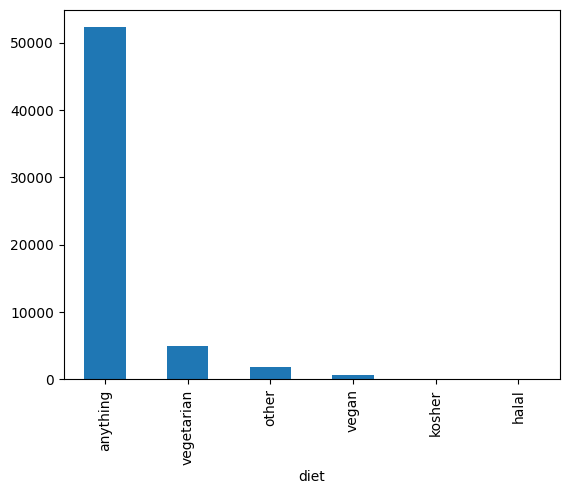

In [31]:
profiles["diet"].value_counts().plot(kind="bar")
plt.show()
plt.close()

Kosher and halal have much less impact rather than the other variables, let's see their percentages

In [32]:
profiles["diet"].value_counts(normalize=True)

diet
anything      0.872052
vegetarian    0.083175
other         0.029860
vegan         0.011711
kosher        0.001918
halal         0.001284
Name: proportion, dtype: float64

We can group this variables into "other" because it represents less than 1%

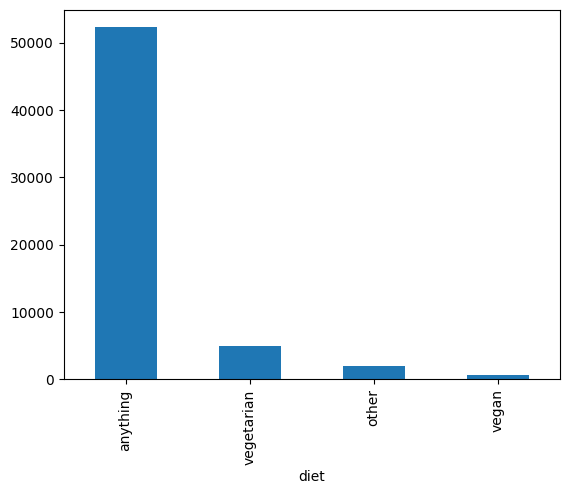

In [33]:
profiles["diet"] = profiles["diet"].apply(lambda x: "other" if "halal" in x or "kosher" in x else x)
profiles["diet"].value_counts().plot(kind="bar")
plt.show()
plt.close()